# autogluon residual method

In [1]:
import pandas as pd
import numpy as np
import nucml.datasets as nuc_data
from autogluon.tabular import TabularPredictor
import matplotlib.pyplot as plt
import os

# Set global target
target_iso = '241Am'

/opt/anaconda3/envs/ml_msci_v2/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# 1. Load EXFOR (Reaction Data)
exfor_df = nuc_data.load_exfor()
exfor_df['MT'] = pd.to_numeric(exfor_df['MT'], errors='coerce')
# Filter for Fission (18) and Actinides (Z >= 89)
actinides = exfor_df[(exfor_df['MT'] == 18) & (exfor_df['Z'] >= 89)].copy()

# 2. Load RIPL/ENSDF (Nuclear Structure)
ensdf_ml, _, _, _, _, _, _ = nuc_data.load_ensdf_ml(cutoff=False, append_ame=True, basic=1, num=True)
ripl_grouped = ensdf_ml.groupby(['Z', 'A']).mean().reset_index()

# 3. Merge EXFOR + RIPL
master_df = pd.merge(actinides, ripl_grouped, on=['Z', 'A'], how='left', suffixes=('_exfor', '_ripl'))

# 4. Apply Fast Regime Filter (> 200 keV)
energy_col = 'Energy_exfor' if 'Energy_exfor' in master_df.columns else 'Energy'
df_fast = master_df[master_df[energy_col] >= 200000].copy()

# 5. Feature Selection
features = [energy_col, 'Z', 'A', 'Binding_Energy_exfor', 'S(n)_exfor', 'Level_Number']
target = 'Data'
df_ml = df_fast[features + [target, 'Isotope']].dropna().copy()

INFO:root: MODE: neutrons
INFO:root: LOW ENERGY: False
INFO:root: LOG: False
INFO:root: BASIC: -1
INFO:root:Reading data from /Users/glsw/main/NucMLClone2/EXFOR/CSV_Files/EXFOR_neutrons/EXFOR_neutrons_MF3_AME_no_RawNaN.csv
INFO:root:Data read into dataframe with shape: (4395295, 104)
INFO:root:Finished. Resulting dataset has shape (4395295, 104)
INFO:root:AME: Reading and loading Atomic Mass Evaluation files from: 
 /Users/glsw/main/NucMLClone2/AME/CSV_Files/AME_all_merged_no_NaN.csv
INFO:root:Dropping unnecessary features and one-hot encoding categorical columns...
INFO:root:Splitting dataset into training and testing...
INFO:root:Normalizing dataset...
INFO:root:Fitting new scaler.
INFO:root:Finished. Resulting dataset has shape (72667, 12), Training and Testing dataset shapes are (50866, 11) and (21801, 11) respesctively.


INFO:root:EVALUATION: Extracting data from /Users/glsw/main/NucMLClone2/Evaluated_Data/neutrons/Ac227/endfb8.0/tables/xs/n-Ac227-MT018.endfb8.0
/opt/anaconda3/envs/ml_msci_v2/lib/python3.10/site-packages/nucml/datasets.py:149: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  evaluation = pd.read_csv(path, skiprows=5, header=None, names=["Energy", "Data", "dDataLow", "dDataUpp"], delim_whitespace=True)
INFO:root:EVALUATION: Converting MeV to eV...
INFO:root:EVALUATION: Converting mb to b...
INFO:root:EVALUATION: Finished. ENDF data contains 891 datapoints.
INFO:root:EVALUATION: Extracting data from /Users/glsw/main/NucMLClone2/Evaluated_Data/neutrons/Th228/endfb8.0/tables/xs/n-Th228-MT018.endfb8.0
/opt/anaconda3/envs/ml_msci_v2/lib/python3.10/site-packages/nucml/datasets.py:149: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. 

Calculating Residuals across all Actinides...
Skipping 231Th: Evaluation file does not exists at /Users/glsw/main/NucMLClone2/Evaluated_Data/neutrons/Th231/endfb8.0/tables/xs/n-Th231-MT018.endfb8.0
Skipping 229Pa: Evaluation file does not exists at /Users/glsw/main/NucMLClone2/Evaluated_Data/neutrons/Pa229/endfb8.0/tables/xs/n-Pa229-MT018.endfb8.0
Skipping 230Pa: Evaluation file does not exists at /Users/glsw/main/NucMLClone2/Evaluated_Data/neutrons/Pa230/endfb8.0/tables/xs/n-Pa230-MT018.endfb8.0
Skipping 232Pa: Evaluation file does not exists at /Users/glsw/main/NucMLClone2/Evaluated_Data/neutrons/Pa232/endfb8.0/tables/xs/n-Pa232-MT018.endfb8.0
Skipping 233Pa: Evaluation file does not exists at /Users/glsw/main/NucMLClone2/Evaluated_Data/neutrons/Pa233/endfb8.0/tables/xs/n-Pa233-MT018.endfb8.0
Skipping 234Pa: Evaluation file does not exists at /Users/glsw/main/NucMLClone2/Evaluated_Data/neutrons/Pa234/endfb8.0/tables/xs/n-Pa234-MT018.endfb8.0
Skipping 230U: Evaluation file does not ex

INFO:root:EVALUATION: Extracting data from /Users/glsw/main/NucMLClone2/Evaluated_Data/neutrons/Pu238/endfb8.0/tables/xs/n-Pu238-MT018.endfb8.0
/opt/anaconda3/envs/ml_msci_v2/lib/python3.10/site-packages/nucml/datasets.py:149: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  evaluation = pd.read_csv(path, skiprows=5, header=None, names=["Energy", "Data", "dDataLow", "dDataUpp"], delim_whitespace=True)
INFO:root:EVALUATION: Converting MeV to eV...
INFO:root:EVALUATION: Converting mb to b...
INFO:root:EVALUATION: Finished. ENDF data contains 11308 datapoints.
INFO:root:EVALUATION: Extracting data from /Users/glsw/main/NucMLClone2/Evaluated_Data/neutrons/Pu239/endfb8.0/tables/xs/n-Pu239-MT018.endfb8.0
/opt/anaconda3/envs/ml_msci_v2/lib/python3.10/site-packages/nucml/datasets.py:149: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version

Skipping 238Am: Evaluation file does not exists at /Users/glsw/main/NucMLClone2/Evaluated_Data/neutrons/Am238/endfb8.0/tables/xs/n-Am238-MT018.endfb8.0
Skipping 239Am: Evaluation file does not exists at /Users/glsw/main/NucMLClone2/Evaluated_Data/neutrons/Am239/endfb8.0/tables/xs/n-Am239-MT018.endfb8.0
Skipping 240Am: Evaluation file does not exists at /Users/glsw/main/NucMLClone2/Evaluated_Data/neutrons/Am240/endfb8.0/tables/xs/n-Am240-MT018.endfb8.0
Skipping 242Am: Evaluation file does not exists at /Users/glsw/main/NucMLClone2/Evaluated_Data/neutrons/Am242/endfb8.0/tables/xs/n-Am242-MT018.endfb8.0
Skipping 244Am: Evaluation file does not exists at /Users/glsw/main/NucMLClone2/Evaluated_Data/neutrons/Am244/endfb8.0/tables/xs/n-Am244-MT018.endfb8.0
Skipping 240Cm: Evaluation file does not exists at /Users/glsw/main/NucMLClone2/Evaluated_Data/neutrons/Cm240/endfb8.0/tables/xs/n-Cm240-MT018.endfb8.0
Skipping 241Cm: Evaluation file does not exists at /Users/glsw/main/NucMLClone2/Evaluate

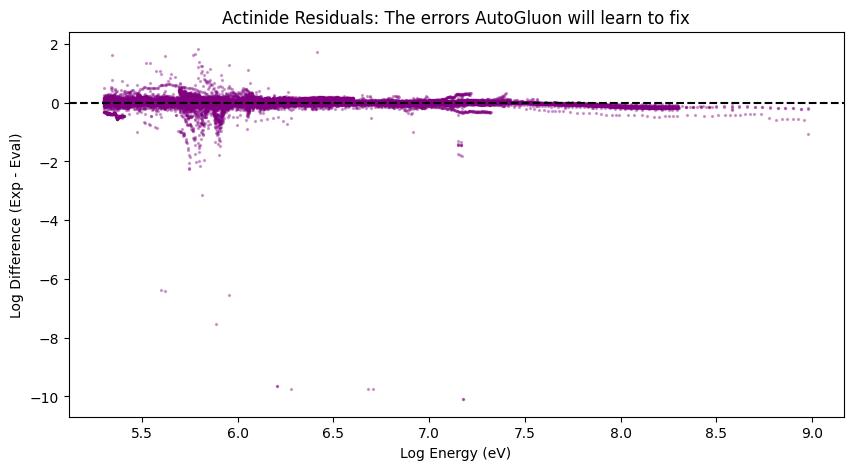

In [4]:
print("Calculating Residuals across all Actinides...")

all_residuals = []

# Loop through each isotope to calculate its specific residuals
for iso in df_ml['Isotope'].unique():
    try:
        # 1. Isolate experimental data for this isotope
        df_iso_exp = df_ml[df_ml['Isotope'] == iso].copy()
        
        # 2. Load the corresponding ENDF evaluation
        df_eval = nuc_data.load_evaluation(iso.lower(), 18, library='endfb8.0')
        
        # Handle Log scales (standardize to Log10 for interpolation)
        e_eval = df_eval['Energy'] if df_eval['Energy'].max() < 100 else np.log10(df_eval['Energy'])
        d_eval = df_eval['Data'] if df_eval['Data'].max() < 10 else np.log10(df_eval['Data'] + 1e-10)
        
        e_exp_log = np.log10(df_iso_exp[energy_col])
        d_exp_log = np.log10(df_iso_exp[target] + 1e-10)

        # 3. Interpolate Evaluated curve onto Experimental Energy points
        # "What did ENDF think the value was at this exact experimental energy?"
        interp_vals = np.interp(e_exp_log, e_eval, d_eval)

        # 4. Calculate the Residual (Log Difference)
        df_iso_exp['residual'] = d_exp_log - interp_vals
        
        # 5. Add Physics Context (Magic Numbers & Shell Effects)
        df_iso_exp['N'] = df_iso_exp['A'] - df_iso_exp['Z']
        df_iso_exp['magic_dist'] = abs(df_iso_exp['N'] - 126) # Distance to N=126 shell
        
        all_residuals.append(df_iso_exp)
    except Exception as e:
        print(f"Skipping {iso}: {e}")

# Recombine into a single training dataframe
df_res_final = pd.concat(all_residuals)
print(f"Residual Data Prepared with {len(df_res_final)} rows across {len(all_residuals)} isotopes.")

# Plot Residuals to verify they are centered near 0
plt.figure(figsize=(10, 5))
plt.scatter(np.log10(df_res_final[energy_col]), df_res_final['residual'], s=2, alpha=0.3, color='purple')
plt.axhline(0, color='k', linestyle='--')
plt.title("Actinide Residuals: The errors AutoGluon will learn to fix")
plt.ylabel("Log Difference (Exp - Eval)")
plt.xlabel("Log Energy (eV)")
plt.show()

In [5]:
# 1. Prepare Training Data (Leave-One-Out)
# We exclude Am-241 so we can test the "correction" on an unseen isotope
train_data = df_res_final[df_res_final['Isotope'] != target_iso].copy()

# Select only the features you defined
features_res = [energy_col, 'Z', 'A', 'N', 'magic_dist', 'Binding_Energy_exfor', 'S(n)_exfor', 'Level_Number']
train_subset = train_data[features_res + ['residual']]

print(f"Training AutoGluon on {len(train_subset)} points...")

# 2. Fit AutoGluon
predictor_res = TabularPredictor(label='residual', eval_metric='mean_absolute_error').fit(
    train_subset, 
    presets='best_quality', 
    time_limit=600
)

No path specified. Models will be saved in: "AutogluonModels/ag-20260127_122612"
Verbosity: 2 (Standard Logging)
=================== System Info ===================
AutoGluon Version:  1.4.0
Python Version:     3.10.19
Operating System:   Darwin
Platform Machine:   arm64
Platform Version:   Darwin Kernel Version 25.2.0: Tue Nov 18 21:09:40 PST 2025; root:xnu-12377.61.12~1/RELEASE_ARM64_T6000
CPU Count:          8
Memory Avail:       4.61 GB / 16.00 GB (28.8%)
Disk Space Avail:   290.41 GB / 460.43 GB (63.1%)
Presets specified: ['best_quality']
Using hyperparameters preset: hyperparameters='zeroshot'
Setting dynamic_stacking from 'auto' to True. Reason: Enable dynamic_stacking when use_bag_holdout is disabled. (use_bag_holdout=False)
Stack configuration (auto_stack=True): num_stack_levels=1, num_bag_folds=8, num_bag_sets=1
DyStack is enabled (dynamic_stacking=True). AutoGluon will try to determine whether the input data is affected by stacked overfitting and enable or disable stacking a

Training AutoGluon on 32360 points...


2026-01-27 12:26:12,697	INFO util.py:154 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.
	Running DyStack sub-fit in a ray process to avoid memory leakage. Enabling ray logging (enable_ray_logging=True). Specify `ds_args={'enable_ray_logging': False}` if you experience logging issues.
2026-01-27 12:26:13,877	INFO worker.py:1843 -- Started a local Ray instance. View the dashboard at 127.0.0.1:8268 
		Context path: "/Users/glsw/main/AutogluonModels/ag-20260127_122612/ds_sub_fit/sub_fit_ho"
(_dystack pid=55178) Running DyStack sub-fit ...
(_dystack pid=55178) Beginning AutoGluon training ... Time limit = 148s
(_dystack pid=55178) AutoGluon will save models to "/Users/glsw/main/AutogluonModels/ag-20260127_122612/ds_sub_fit/sub_fit_ho"
(_dystack pid=55178) Train Data Rows:    28764
(_dystack pid=55178) Train Data Columns: 8
(_dystack pid=55178) Label Column:       residual
(_dystack pid=55178) Problem Type:    

(_ray_fit pid=55193) [1000]	valid_set's l1: 0.0458556
(_ray_fit pid=55193) [5000]	valid_set's l1: 0.0448128 [repeated 25x across cluster] (Ray deduplicates logs by default. Set RAY_DEDUP_LOGS=0 to disable log deduplication, or see https://docs.ray.io/en/master/ray-observability/user-guides/configure-logging.html#log-deduplication for more options.)
(_ray_fit pid=55194) [10000]	valid_set's l1: 0.045496 [repeated 23x across cluster]


(_dystack pid=55178) 	-0.045	 = Validation score   (-mean_absolute_error)
(_dystack pid=55178) 	14.06s	 = Training   runtime
(_dystack pid=55178) 	16.69s	 = Validation runtime
(_dystack pid=55178) Fitting model: LightGBM_BAG_L1 ... Training model for up to 76.93s of the 126.24s of remaining time.
(_dystack pid=55178) 	Fitting 8 child models (S1F1 - S1F8) | Fitting with ParallelLocalFoldFittingStrategy (8 workers, per: cpus=1, gpus=0, memory=0.41%)
(_dystack pid=55178) 	-0.0449	 = Validation score   (-mean_absolute_error)
(_dystack pid=55178) 	0.94s	 = Training   runtime
(_dystack pid=55178) 	0.44s	 = Validation runtime
(_dystack pid=55178) Fitting model: RandomForestMSE_BAG_L1 ... Training model for up to 74.01s of the 123.32s of remaining time.
(_dystack pid=55178) 	-0.0539	 = Validation score   (-mean_absolute_error)
(_dystack pid=55178) 	3.12s	 = Training   runtime
(_dystack pid=55178) 	0.82s	 = Validation runtime
(_dystack pid=55178) Fitting model: CatBoost_BAG_L1 ... Training mode

>>> Step 5: Visualizing ML-Corrected Evaluation vs Benchmarks...


INFO:root:EVALUATION: Extracting data from /Users/glsw/main/NucMLClone2/Evaluated_Data/neutrons/Am241/endfb8.0/tables/xs/n-Am241-MT018.endfb8.0
/opt/anaconda3/envs/ml_msci_v2/lib/python3.10/site-packages/nucml/datasets.py:149: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  evaluation = pd.read_csv(path, skiprows=5, header=None, names=["Energy", "Data", "dDataLow", "dDataUpp"], delim_whitespace=True)
INFO:root:EVALUATION: Converting MeV to eV...
INFO:root:EVALUATION: Converting mb to b...
INFO:root:EVALUATION: Finished. ENDF data contains 16294 datapoints.
INFO:root:EVALUATION: Extracting data from /Users/glsw/main/NucMLClone2/Evaluated_Data/neutrons/Am241/tendl.2019/tables/xs/n-Am241-MT018.tendl.2019
/opt/anaconda3/envs/ml_msci_v2/lib/python3.10/site-packages/nucml/datasets.py:149: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future ver

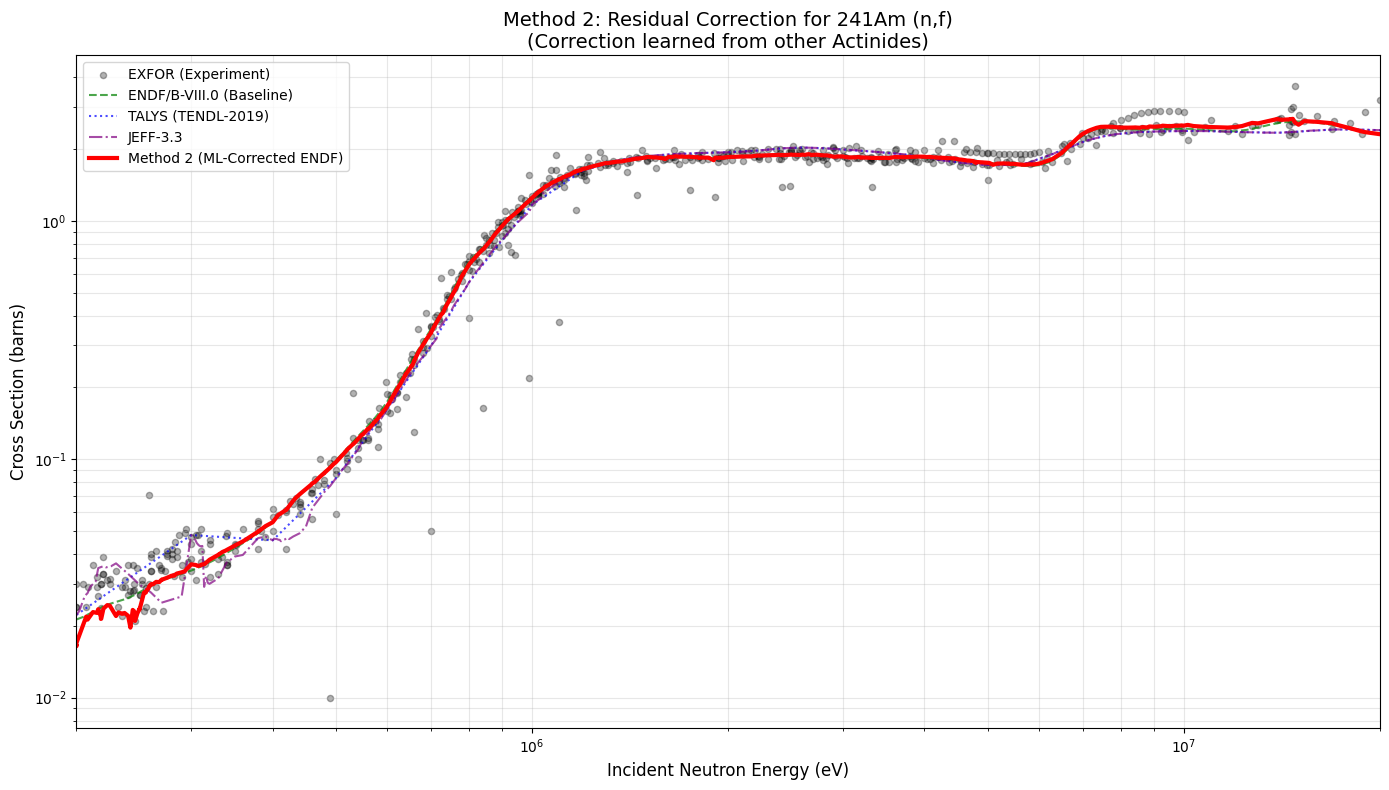

In [7]:
# ==========================================
# 7. ANALYSIS & VISUALIZATION (METHOD 2)
# ==========================================
print(">>> Step 5: Visualizing ML-Corrected Evaluation vs Benchmarks...")

# 1. Prepare Am-241 test features
test_iso_df = df_res_final[df_res_final['Isotope'] == target_iso].copy()
test_features = test_iso_df[features_res]

# 2. Predict the Correction (Residual)
test_iso_df['predicted_residual'] = predictor_res.predict(test_features)

# 3. Apply Correction to the original ENDF curve
# Corrected = 10^(Log10(Original) + Prediction)
# Note: Residuals were calculated as (LogExp - LogEval)
test_iso_df['ML_Corrected'] = 10**(np.log10(test_iso_df['Data'] / (10**test_iso_df['residual'])) + test_iso_df['predicted_residual'])

# 4. Setup Plot
plt.figure(figsize=(14, 8))

# 5. Plot Experimental Data (EXFOR)
plt.scatter(test_iso_df[energy_col], test_iso_df['Data'], color='black', s=20, alpha=0.3, label='EXFOR (Experiment)')

# --- HELPER FUNCTION FOR OVERLAYING LIBRARIES ---
def overlay_library(iso, mt, lib, color, style, label):
    try:
        df = nuc_data.load_evaluation(iso, mt, library=lib)
        if not df.empty:
            e = 10**df['Energy'] if df['Energy'].max() < 100 else df['Energy']
            d = 10**df['Data'] if df['Data'].max() < 10 else df['Data']
            mask = e >= 2e5 # Fast Regime only
            plt.plot(e[mask], d[mask], color=color, linestyle=style, linewidth=1.5, label=label, alpha=0.7)
    except:
        pass

# 6. Plot Benchmark Libraries
overlay_library("am241", 18, "endfb8.0", "green", "--", "ENDF/B-VIII.0 (Baseline)")
overlay_library("am241", 18, "tendl.2019", "blue", ":", "TALYS (TENDL-2019)")
overlay_library("am241", 18, "jeff3.3", "purple", "-.", "JEFF-3.3")

# 7. Plot Your ML-Corrected Evaluation
sort_idx = np.argsort(test_iso_df[energy_col].values)
plt.plot(test_iso_df[energy_col].values[sort_idx], test_iso_df['ML_Corrected'].values[sort_idx], 
         color='red', linewidth=3, label='Method 2 (ML-Corrected ENDF)')

# 8. Final Formatting
plt.xscale('log'); plt.yscale('log')
plt.xlim(2e5, 2e7)
plt.xlabel('Incident Neutron Energy (eV)', fontsize=12)
plt.ylabel('Cross Section (barns)', fontsize=12)
plt.title(f'Method 2: Residual Correction for {target_iso} (n,f)\n(Correction learned from other Actinides)', fontsize=14)
plt.legend(loc='upper left', fontsize=10)
plt.grid(True, which="both", alpha=0.3)
plt.tight_layout()
plt.show()

>>> Executing Method 2: Residual Correction Analysis...


INFO:root:EVALUATION: Extracting data from /Users/glsw/main/NucMLClone2/Evaluated_Data/neutrons/Am241/endfb8.0/tables/xs/n-Am241-MT018.endfb8.0
/opt/anaconda3/envs/ml_msci_v2/lib/python3.10/site-packages/nucml/datasets.py:149: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  evaluation = pd.read_csv(path, skiprows=5, header=None, names=["Energy", "Data", "dDataLow", "dDataUpp"], delim_whitespace=True)
INFO:root:EVALUATION: Converting MeV to eV...
INFO:root:EVALUATION: Converting mb to b...
INFO:root:EVALUATION: Finished. ENDF data contains 16294 datapoints.
INFO:root:EVALUATION: Extracting data from /Users/glsw/main/NucMLClone2/Evaluated_Data/neutrons/Am241/tendl.2019/tables/xs/n-Am241-MT018.tendl.2019
/opt/anaconda3/envs/ml_msci_v2/lib/python3.10/site-packages/nucml/datasets.py:149: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future ver

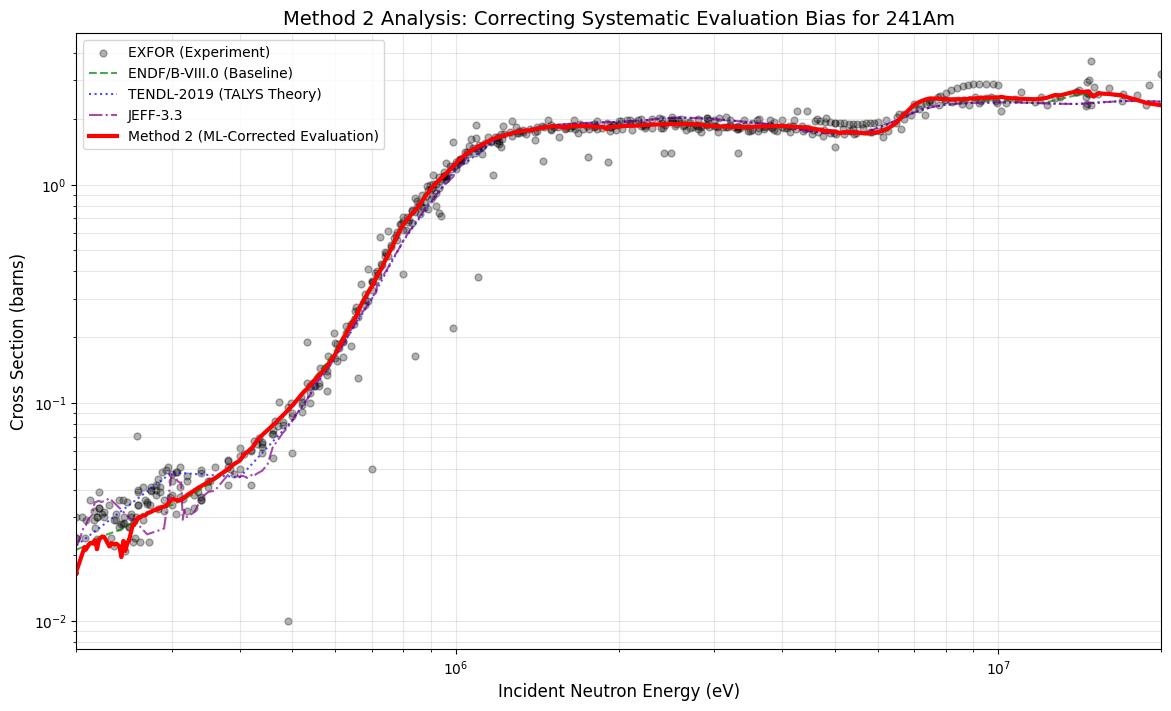

Original Evaluation Error (Log-MAE): 0.0442
ML-Corrected Evaluation Error (Log-MAE): 0.0460
Total Bias Reduction: -4.23%


In [9]:
# ==========================================
# 7. FINAL METHOD 2 ANALYSIS & PLOT
# ==========================================
print(">>> Executing Method 2: Residual Correction Analysis...")

# 1. Predict correction for Am-241
test_iso_df = df_res_final[df_res_final['Isotope'] == target_iso].copy()
test_iso_df['predicted_residual'] = predictor_res.predict(test_iso_df[features_res])

# 2. Reconstruct ML-Corrected Curve
# Note: original_endf is recovered from the inverse of your residual calc
test_iso_df['Original_ENDF'] = 10**(np.log10(test_iso_df[target]) - test_iso_df['residual'])
test_iso_df['ML_Corrected'] = 10**(np.log10(test_iso_df['Original_ENDF']) + test_iso_df['predicted_residual'])

# 3. Visualization
plt.figure(figsize=(14, 8))
plt.scatter(test_iso_df[energy_col], test_iso_df[target], color='black', s=25, alpha=0.3, label='EXFOR (Experiment)')

# Plot Benchmarks
overlay_library("am241", 18, "endfb8.0", "green", "--", "ENDF/B-VIII.0 (Baseline)")
overlay_library("am241", 18, "tendl.2019", "blue", ":", "TENDL-2019 (TALYS Theory)")
overlay_library("am241", 18, "jeff3.3", "purple", "-.", "JEFF-3.3")

# Plot Method 2 Correction
sort_idx = np.argsort(test_iso_df[energy_col].values)
plt.plot(test_iso_df[energy_col].values[sort_idx], test_iso_df['ML_Corrected'].values[sort_idx], 
         color='red', linewidth=3, label='Method 2 (ML-Corrected Evaluation)')

# Formatting
plt.xscale('log'); plt.yscale('log'); plt.xlim(2e5, 2e7)
plt.xlabel('Incident Neutron Energy (eV)', fontsize=12); plt.ylabel('Cross Section (barns)', fontsize=12)
plt.title(f'Method 2 Analysis: Correcting Systematic Evaluation Bias for {target_iso}', fontsize=14)
plt.legend(loc='upper left', fontsize=10); plt.grid(True, which="both", alpha=0.3)
plt.show()

# Quantitative Improvement Check
original_mae = np.mean(abs(test_iso_df['residual']))
corrected_mae = np.mean(abs(test_iso_df['residual'] - test_iso_df['predicted_residual']))
print(f"Original Evaluation Error (Log-MAE): {original_mae:.4f}")
print(f"ML-Corrected Evaluation Error (Log-MAE): {corrected_mae:.4f}")
print(f"Total Bias Reduction: {((original_mae - corrected_mae) / original_mae)*100:.2f}%")

Computing feature importance via permutation shuffling for 8 features using 573 rows with 5 shuffle sets...


>>> Calculating Feature Importance for 241Am residuals...


	156.05s	= Expected runtime (31.21s per shuffle set)
	35.97s	= Actual runtime (Completed 5 of 5 shuffle sets)


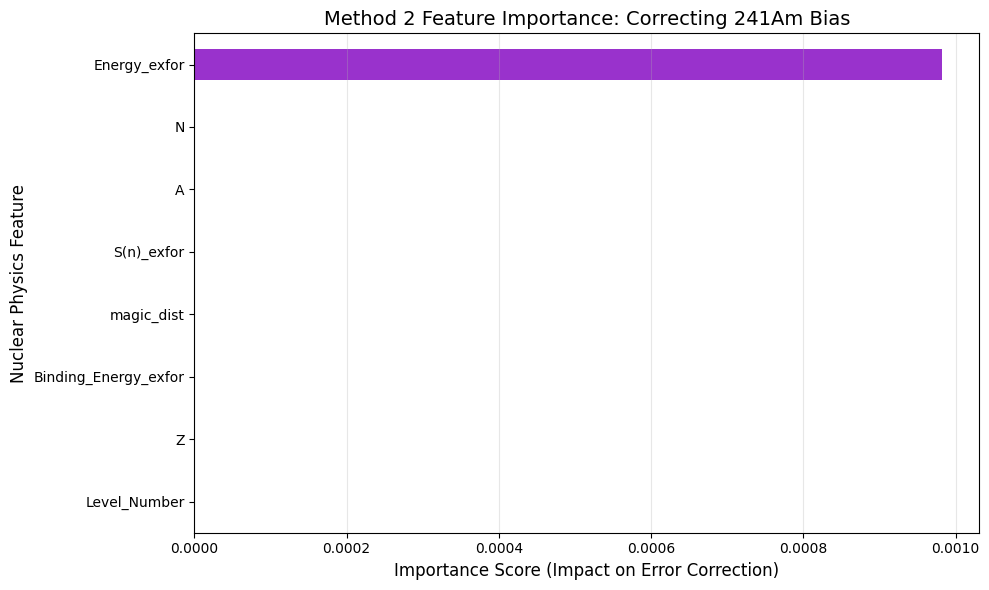

                        importance    stddev   p_value  n      p99_high  \
Energy_exfor          9.819817e-04  0.000882  0.033726  5  2.797364e-03   
N                     1.857972e-09  0.000000  0.500000  5  1.857972e-09   
A                     1.638297e-09  0.000000  0.500000  5  1.638297e-09   
S(n)_exfor            1.082073e-09  0.000000  0.500000  5  1.082073e-09   
magic_dist            9.745974e-10  0.000000  0.500000  5  9.745974e-10   
Binding_Energy_exfor  8.628549e-10  0.000000  0.500000  5  8.628549e-10   
Z                     5.375828e-10  0.000000  0.500000  5  5.375828e-10   
Level_Number          8.634644e-11  0.000000  0.500000  5  8.634644e-11   

                           p99_low  
Energy_exfor         -8.334010e-04  
N                     1.857972e-09  
A                     1.638297e-09  
S(n)_exfor            1.082073e-09  
magic_dist            9.745974e-10  
Binding_Energy_exfor  8.628549e-10  
Z                     5.375828e-10  
Level_Number          8.6346

In [11]:
# ==========================================
# 8. FEATURE IMPORTANCE (RESIDUAL METHOD)
# ==========================================
print(f">>> Calculating Feature Importance for {target_iso} residuals...")

# 1. Identify the correct test data from your Method 2 notebook
# In Method 2, we use the Am-241 specific dataframe created for prediction
if 'test_iso_df' in locals():
    importance_test_data = test_iso_df[features_res + ['residual']]
elif 'test_subset' in locals():
    importance_test_data = test_subset
else:
    # Fallback: Re-create it if it was dropped
    importance_test_data = df_res_final[df_res_final['Isotope'] == target_iso][features_res + ['residual']]

# 2. Calculate Importance
importance = predictor_res.feature_importance(importance_test_data)

# 3. Plotting
plt.figure(figsize=(10, 6))
importance['importance'].sort_values().plot(kind='barh', color='darkorchid')
plt.title(f'Method 2 Feature Importance: Correcting {target_iso} Bias', fontsize=14)
plt.xlabel('Importance Score (Impact on Error Correction)', fontsize=12)
plt.ylabel('Nuclear Physics Feature', fontsize=12)
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

print(importance)

# Begininng testing 

In [1]:
import pandas as pd
import nucml.datasets as nuc_data

# 1. Load EXFOR for (n,2n) reactions (MT=16)
exfor_df = nuc_data.load_exfor()
exfor_df['MT'] = pd.to_numeric(exfor_df['MT'], errors='coerce')
n2n_df = exfor_df[exfor_df['MT'] == 16].copy()

# 2. Define Mass Regions
regions = {
    "Low-A (20-60)": (20, 60),
    "Mid-A (60-100)": (60, 100),
    "High-A (100-200)": (100, 200)
}

print("Searching for (n,2n) candidates...")
print(f"{'Region':<20} | {'Isotope':<10} | {'Data Points':<12}")
print("-" * 50)

for name, (min_a, max_a) in regions.items():
    # Filter by mass range
    mask = (n2n_df['A'] >= min_a) & (n2n_df['A'] < max_a)
    region_df = n2n_df[mask]
    
    # Get counts per isotope
    counts = region_df['Isotope'].value_counts()
    
    if not counts.empty:
        # High-data candidate
        high_iso = counts.index[0]
        high_val = counts.iloc[0]
        
        # Minimal-data candidate (filtering for at least 5 points for validation)
        min_candidates = counts[counts >= 5]
        low_iso = min_candidates.index[-1]
        low_val = min_candidates.iloc[-1]
        
        print(f"{name:<20} | {high_iso:<10} | {high_val:<12} (Abundant)")
        print(f"{name:<20} | {low_iso:<10} | {low_val:<12} (Minimal)")
        print("-" * 50)

INFO:root: MODE: neutrons
INFO:root: LOW ENERGY: False
INFO:root: LOG: False
INFO:root: BASIC: -1
INFO:root:Reading data from /Users/glsw/main/NucMLClone2/EXFOR/CSV_Files/EXFOR_neutrons/EXFOR_neutrons_MF3_AME_no_RawNaN.csv
INFO:root:Data read into dataframe with shape: (4395295, 104)
INFO:root:Finished. Resulting dataset has shape (4395295, 104)


Searching for (n,2n) candidates...
Region               | Isotope    | Data Points 
--------------------------------------------------
Low-A (20-60)        | 58Ni       | 522          (Abundant)
Low-A (20-60)        | 28Si       | 5            (Minimal)
--------------------------------------------------
Mid-A (60-100)       | 93Nb       | 372          (Abundant)
Mid-A (60-100)       | 80Kr       | 5            (Minimal)
--------------------------------------------------
High-A (100-200)     | 197Au      | 507          (Abundant)
High-A (100-200)     | 164Er      | 5            (Minimal)
--------------------------------------------------


In [2]:
import pandas as pd
import numpy as np
import nucml.datasets as nuc_data
from autogluon.tabular import TabularPredictor
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# 1. Define Regions and Target Isotopes
target_isos = ['58Ni', '28Si', '93Nb', '80Kr', '197Au', '164Er']

# 2. Load Reaction Data (MT=16 is n,2n)
exfor_df = nuc_data.load_exfor()
exfor_df['MT'] = pd.to_numeric(exfor_df['MT'], errors='coerce')
df_n2n = exfor_df[(exfor_df['MT'] == 16) & (exfor_df['A'] >= 20) & (exfor_df['A'] <= 200)].copy()

# 3. Load Physics Data (RIPL/AME)
ensdf_ml, _, _, _, _, _, _ = nuc_data.load_ensdf_ml(cutoff=False, append_ame=True, basic=1, num=True)
ripl_grouped = ensdf_ml.groupby(['Z', 'A']).mean().reset_index()

# 4. Merge
df_ml = pd.merge(df_n2n, ripl_grouped, on=['Z', 'A'], how='left', suffixes=('_exfor', '_ripl')).dropna(subset=['S(n)_exfor', 'Data']).copy()

/opt/anaconda3/envs/ml_msci_v2/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
INFO:root: MODE: neutrons
INFO:root: LOW ENERGY: False
INFO:root: LOG: False
INFO:root: BASIC: -1
INFO:root:Reading data from /Users/glsw/main/NucMLClone2/EXFOR/CSV_Files/EXFOR_neutrons/EXFOR_neutrons_MF3_AME_no_RawNaN.csv
INFO:root:Data read into dataframe with shape: (4395295, 104)
INFO:root:Finished. Resulting dataset has shape (4395295, 104)
INFO:root:AME: Reading and loading Atomic Mass Evaluation files from: 
 /Users/glsw/main/NucMLClone2/AME/CSV_Files/AME_all_merged_no_NaN.csv
INFO:root:Dropping unnecessary features and one-hot encoding categorical columns...
INFO:root:Splitting dataset into training and testing...
INFO:root:Normalizing dataset...
INFO:root:Fitting new scaler.
INFO:root:Finished. Resulting dataset has 

INFO:root:EVALUATION: Extracting data from /Users/glsw/main/NucMLClone2/Evaluated_Data/neutrons/Na023/endfb8.0/tables/xs/n-Na023-MT016.endfb8.0
/opt/anaconda3/envs/ml_msci_v2/lib/python3.10/site-packages/nucml/datasets.py:149: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  evaluation = pd.read_csv(path, skiprows=5, header=None, names=["Energy", "Data", "dDataLow", "dDataUpp"], delim_whitespace=True)
INFO:root:EVALUATION: Converting MeV to eV...
INFO:root:EVALUATION: Converting mb to b...
/opt/anaconda3/envs/ml_msci_v2/lib/python3.10/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
INFO:root:EVALUATION: Finished. ENDF data contains 12 datapoints.
/opt/anaconda3/envs/ml_msci_v2/lib/python3.10/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log10
  result

Calculating Baseline Residuals (Log Exp - Log Eval)...


/opt/anaconda3/envs/ml_msci_v2/lib/python3.10/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
INFO:root:EVALUATION: Extracting data from /Users/glsw/main/NucMLClone2/Evaluated_Data/neutrons/Se074/endfb8.0/tables/xs/n-Se074-MT016.endfb8.0
/opt/anaconda3/envs/ml_msci_v2/lib/python3.10/site-packages/nucml/datasets.py:149: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  evaluation = pd.read_csv(path, skiprows=5, header=None, names=["Energy", "Data", "dDataLow", "dDataUpp"], delim_whitespace=True)
INFO:root:EVALUATION: Converting MeV to eV...
INFO:root:EVALUATION: Converting mb to b...
/opt/anaconda3/envs/ml_msci_v2/lib/python3.10/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
INFO:root:EVALUATION:

Cleaned 7188 non-finite rows. Remaining: 3155


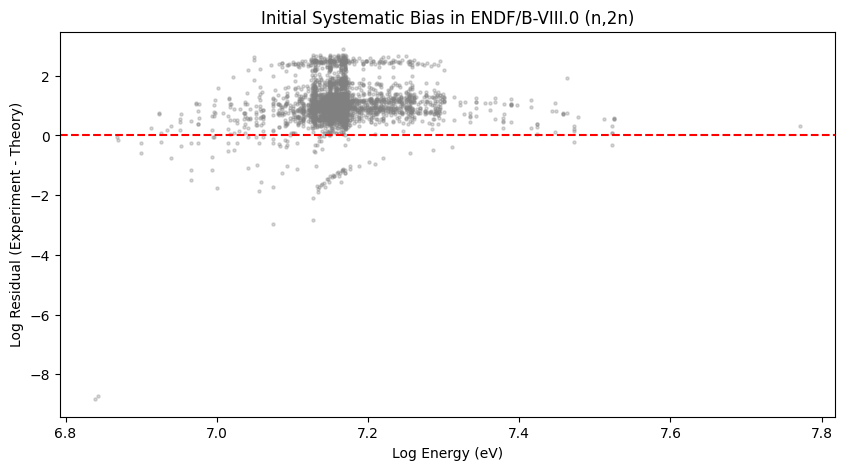

In [6]:
print("Calculating Baseline Residuals (Log Exp - Log Eval)...")
all_residuals = []

for iso in df_ml['Isotope'].unique():
    try:
        df_iso = df_ml[df_ml['Isotope'] == iso].copy()
        df_eval = nuc_data.load_evaluation(iso.lower(), 16, library='endfb8.0')
        
        # Grid alignment in Log-Space
        e_eval = np.log10(df_eval['Energy'])
        # Add 1e-10 to avoid log(0) = -inf
        d_eval = np.log10(df_eval['Data'] + 1e-10)
        
        interp_theory = np.interp(np.log10(df_iso['Energy_exfor']), e_eval, d_eval)
        
        df_iso['label_log'] = np.log10(df_iso['Data'] + 1e-10)
        df_iso['residual'] = df_iso['label_log'] - interp_theory
        
        # Add context for shell effects
        df_iso['N'] = df_iso['A'] - df_iso['Z']
        df_iso['magic_dist'] = abs(df_iso['N'] - 126) 
        
        all_residuals.append(df_iso)
    except Exception: continue

df_res_final = pd.concat(all_residuals)

# --- CRITICAL CLEANING STEP ---
# Remove any NaN or Inf residuals before training
initial_count = len(df_res_final)
df_res_final = df_res_final[np.isfinite(df_res_final['residual'])].copy()
print(f"Cleaned {initial_count - len(df_res_final)} non-finite rows. Remaining: {len(df_res_final)}")

# DIAGNOSTIC: Initial Bias Visualization
plt.figure(figsize=(10, 5))
plt.scatter(np.log10(df_res_final['Energy_exfor']), df_res_final['residual'], alpha=0.3, s=5, color='gray')
plt.axhline(0, color='red', linestyle='--')
plt.title("Initial Systematic Bias in ENDF/B-VIII.0 (n,2n)")
plt.ylabel("Log Residual (Experiment - Theory)")
plt.xlabel("Log Energy (eV)")
plt.show()

In [7]:
import seaborn as sns
from sklearn.preprocessing import StandardScaler

# 1. Feature Engineering
df_res_final['Energy_Log'] = np.log10(df_res_final['Energy_exfor'])
# Sn is in MeV, convert to match eV log scale
df_res_final['E_minus_Sn'] = df_res_final['Energy_Log'] - np.log10(df_res_final['S(n)_exfor'] * 1e6)

# Expanded feature list for better physics capture
features = ['Energy_Log', 'E_minus_Sn', 'Z', 'A', 'Binding_Energy_exfor', 'S(n)_exfor', 'Level_Number']

# 2. SPLIT FIRST (Crucial for Rigor)
train_res_raw = df_res_final[~df_res_final['Isotope'].isin(target_isos)].copy()
test_res_raw = df_res_final[df_res_final['Isotope'].isin(target_isos)].copy()

# 3. SCALE ONLY ON TRAINING DATA
scaler = StandardScaler()
train_res_scaled = train_res_raw.copy()
train_res_scaled[features] = scaler.fit_transform(train_res_raw[features])

# 4. APPLY TRAINING SCALE TO TEST DATA (No Leakage)
test_res_scaled = test_res_raw.copy()
test_res_scaled[features] = scaler.transform(test_res_raw[features])

# Final Check: Ensure no NaNs exist in the training subset
train_res_scaled = train_res_scaled.dropna(subset=features + ['residual'])

print(f"Final training set size: {len(train_res_scaled)}")

Final training set size: 3150


In [ ]:
import ray
import gc

# 1. Shutdown any existing Ray workers using your RAM
if ray.is_initialized():
    ray.shutdown()

# 2. Force Python to release memory back to macOS
gc.collect()

print("Ray workers cleared. Memory pressure should begin to drop in Activity Monitor.")

Ray workers cleared. Memory pressure should begin to drop in Activity Monitor.


: 

In [8]:
# 2700 seconds = 45 minutes
time_limit_sec = 45 * 60 

print(f">>> Training AutoGluon Residual Auditor for {time_limit_sec/60} minutes...")

predictor_res = TabularPredictor(label='residual', eval_metric='mean_absolute_error').fit(
    train_res_scaled[features + ['residual']], 
    presets='best_quality', 
    time_limit=time_limit_sec,
    dynamic_stacking=True # Allows DyStack to optimize levels
)

No path specified. Models will be saved in: "AutogluonModels/ag-20260203_123828"
Verbosity: 2 (Standard Logging)
=================== System Info ===================
AutoGluon Version:  1.4.0
Python Version:     3.10.19
Operating System:   Darwin
Platform Machine:   arm64
Platform Version:   Darwin Kernel Version 25.2.0: Tue Nov 18 21:09:40 PST 2025; root:xnu-12377.61.12~1/RELEASE_ARM64_T6000
CPU Count:          8
Memory Avail:       4.83 GB / 16.00 GB (30.2%)
Disk Space Avail:   276.38 GB / 460.43 GB (60.0%)
Presets specified: ['best_quality']
Using hyperparameters preset: hyperparameters='zeroshot'
Stack configuration (auto_stack=True): num_stack_levels=1, num_bag_folds=8, num_bag_sets=1
DyStack is enabled (dynamic_stacking=True). AutoGluon will try to determine whether the input data is affected by stacked overfitting and enable or disable stacking as a consequence.
	This is used to identify the optimal `num_stack_levels` value. Copies of AutoGluon will be fit on subsets of the data.

>>> Training AutoGluon Residual Auditor for 45.0 minutes...


KeyboardInterrupt: 